In [1]:
from load_dataset import OSAData
import numpy as np
import matplotlib.pyplot as plt


In [2]:
load=OSAData(r"C:\Users\PC\OneDrive\Pulpit\telemedycyna\Apnea-detection\data")
data=load.load_data()


# Now, we will show how does it work

Data 07 will be our example

In [3]:
data=data[6]

In [4]:
for key, value in data.items():
    if key=='record_start':
        print(f"{key}: {value}")
        break
    print(f"{key}: {len(data[key])} samples")

spo2_time: 25040 samples
spo2_values: 25040 samples
annotation: 58 samples
record_start: 76899.0


In [5]:
print(data['annotation'][:5])

[{'event_type': 'osa', 'evnet_start': 87171.0, 'event_duration': 18.2, 'sleep_stage': 'W'}, {'event_type': 'hypo', 'evnet_start': 87211.0, 'event_duration': 16.5, 'sleep_stage': 'N1'}, {'event_type': 'hypo', 'evnet_start': 89601.0, 'event_duration': 16.5, 'sleep_stage': 'W'}, {'event_type': 'hypo', 'evnet_start': 89670.0, 'event_duration': 13.4, 'sleep_stage': 'N2'}, {'event_type': 'hypo', 'evnet_start': 89762.0, 'event_duration': 19.8, 'sleep_stage': 'N1'}]


# OSA event -> Obstructive Sleep Apnea 
# Hypo event -> Hypopnea
# Both are classified as apneic events, but they have different characteristics.

In [6]:
apnea_events=[]

for event in data['annotation'][:5]:
    print(event)
    print(f"event: {event['event_type']}\n start:{event['evnet_start']} \n end:{event['evnet_start']+int(event['event_duration'])}")
    apnea_events.append([event['event_type'],event['evnet_start'],event['evnet_start']+int(event['event_duration'])])

{'event_type': 'osa', 'evnet_start': 87171.0, 'event_duration': 18.2, 'sleep_stage': 'W'}
event: osa
 start:87171.0 
 end:87189.0
{'event_type': 'hypo', 'evnet_start': 87211.0, 'event_duration': 16.5, 'sleep_stage': 'N1'}
event: hypo
 start:87211.0 
 end:87227.0
{'event_type': 'hypo', 'evnet_start': 89601.0, 'event_duration': 16.5, 'sleep_stage': 'W'}
event: hypo
 start:89601.0 
 end:89617.0
{'event_type': 'hypo', 'evnet_start': 89670.0, 'event_duration': 13.4, 'sleep_stage': 'N2'}
event: hypo
 start:89670.0 
 end:89683.0
{'event_type': 'hypo', 'evnet_start': 89762.0, 'event_duration': 19.8, 'sleep_stage': 'N1'}
event: hypo
 start:89762.0 
 end:89781.0


For every event there are two values -> [[start,stop]] of event

In [7]:
spo2_val=data['spo2_values']
spo2_t=data['spo2_time']
print(f"First 5 samples: {spo2_val[:5]}\n First 5 time records: {spo2_t[:5]}")

First 5 samples: [98. 98. 98. 98. 98.]
 First 5 time records: [87159. 87160. 87161. 87162. 87163.]


In [8]:
for event,t_start,t_end in apnea_events:
   mask = (data['spo2_time'] >= t_start) & (data['spo2_time'] <= t_start + 59)
   event_spo2 = data['spo2_values'][mask]
   print(f"[{event}] start={t_start}, duration={t_end-t_start}s")
   print(f"SpO2: {event_spo2}")
   print(f"min={event_spo2.min():.1f}%  drop={event_spo2.max()-event_spo2.min():.1f}pp\n")


[osa] start=87171.0, duration=18.0s
SpO2: [98. 98. 98. 98. 97. 97. 97. 97. 97. 97. 96. 96. 96. 96. 96. 96. 96. 96.
 96. 96. 96. 96. 95. 95. 94. 94. 93. 92. 91. 91. 90. 90. 90. 91. 91. 92.
 92. 93. 93. 94. 94. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95.
 95. 94. 94. 94. 94. 94.]
min=90.0%  drop=8.0pp

[hypo] start=87211.0, duration=16.0s
SpO2: [94. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 94. 94. 94.
 94. 94. 93. 93. 93. 92. 92. 92. 92. 92. 92. 92. 92. 93. 93. 93. 93. 93.
 93. 93. 93. 93. 93. 93. 93. 93. 93. 94. 93. 93. 93. 93. 93. 93. 93. 93.
 93. 93. 93. 93. 94. 94.]
min=92.0%  drop=3.0pp

[hypo] start=89601.0, duration=16.0s
SpO2: [98. 98. 98. 98. 98. 98. 98. 98. 98. 98. 97. 97. 97. 97. 97. 97. 97. 97.
 97. 96. 96. 96. 96. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 96. 96.
 96. 96. 96. 96. 96. 96. 96. 96. 96. 96. 96. 96. 96. 96. 96. 96. 96. 96.
 96. 96. 96. 96. 96. 96.]
min=95.0%  drop=3.0pp

[hypo] start=89670.0, duration=13.0s
SpO2: [96. 96. 96. 96. 96. 96. 

In [9]:
signals=[]
labels=[]


for event,t_start,t_end in apnea_events:
   mask = (data['spo2_time'] >= t_start) & (data['spo2_time'] <= t_start + 59)
   event_spo2 = data['spo2_values'][mask]
   labels.append(event)
   signals.append(event_spo2)




In [10]:
mapping = {
    'osa': 1,
    'hypo': 2
}

labels = [mapping[x] for x in labels]
 

Now we create full dataset of apnea events, not only first 5 examples

In [16]:
apnea_events=[]

for event in data['annotation']:
    apnea_events.append([event['event_type'],event['evnet_start'],event['evnet_start']+int(event['event_duration'])])
spo2_val=data['spo2_values']
spo2_t=data['spo2_time']



signals=[]
labels=[]

for event,t_start,t_end in apnea_events:
   mask = (data['spo2_time'] >= t_start) & (data['spo2_time'] <= t_start + 59)
   event_spo2 = data['spo2_values'][mask]
   if len(event_spo2) == 60:
    labels.append(event)
    signals.append(event_spo2)



mapping = {
    'osa': 1,
    'hypo': 2
}


# Now we have to add signal windows without apnea

In [17]:
WINDOW_SIZE = 60   

# Check if there is an apnea event around (30s before and after)

def find_event(t_win_start,t_win_end,events,margin=30):
    for _,ev_start,ev_end in events:
        if t_win_start < ev_end + margin and t_win_end > ev_start - margin:
            return True
    return False

t_begining=spo2_t[0]+30
t_end=t_begining+60
normal_signals=[]

while t_end<spo2_t[-1]:
    if find_event(t_begining,t_end,apnea_events) == False:
        mask = (data['spo2_time'] >= t_begining) & (data['spo2_time'] < t_end)
        event_spo2 = data['spo2_values'][mask]
        normal_signals.append(event_spo2)
      
    t_begining+=WINDOW_SIZE
    t_end+=WINDOW_SIZE




In [18]:
X = np.array(signals + normal_signals)
y = np.array([mapping[label] for label in labels] + [0] * len(normal_signals))

In [19]:
_,counts=np.unique(y,return_counts=True)

NORMAL SIGNAL -> 0 

OSA -> 1

HYPO -> 2

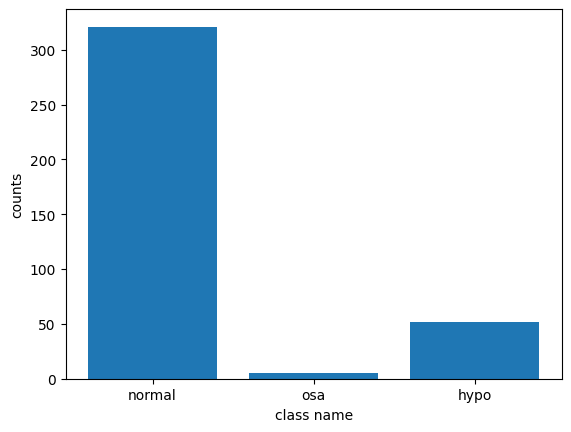

[321   5  52]


In [20]:
class_names=['normal','osa','hypo']

plt.bar(class_names,counts)
plt.xlabel('class name')
plt.ylabel('counts')
plt.show()
print(counts)

# Loading all files

In [2]:
load=OSAData(r"C:\Users\PC\OneDrive\Pulpit\telemedycyna\Apnea-detection\data")
data=load.load_data()

In [3]:
for i in range(len(data)):
    data_num=data[i]
    print(f"Number of file: {i}")
    for key, value in data_num.items():
        if key=='record_start':
            print(f"{key}: {value} \n")
            break
        print(f"{key}: {len(data_num[key])} samples")

Number of file: 0
spo2_time: 35165 samples
spo2_values: 35165 samples
annotation: 86 samples
record_start: 75454.0 

Number of file: 1
spo2_time: 35972 samples
spo2_values: 35972 samples
annotation: 574 samples
record_start: 76230.0 

Number of file: 2
spo2_time: 31308 samples
spo2_values: 31308 samples
annotation: 229 samples
record_start: 77034.0 

Number of file: 3
spo2_time: 30526 samples
spo2_values: 30526 samples
annotation: 38 samples
record_start: 77661.0 

Number of file: 4
spo2_time: 35078 samples
spo2_values: 35078 samples
annotation: 435 samples
record_start: 74267.0 

Number of file: 5
spo2_time: 30278 samples
spo2_values: 30278 samples
annotation: 280 samples
record_start: 76711.0 

Number of file: 6
spo2_time: 25040 samples
spo2_values: 25040 samples
annotation: 58 samples
record_start: 76899.0 

Number of file: 7
spo2_time: 40440 samples
spo2_values: 40440 samples
annotation: 319 samples
record_start: 72528.0 

Number of file: 8
spo2_time: 39036 samples
spo2_values: 390

In [4]:
WINDOW_SIZE = 60   

def find_event(t_win_start,t_win_end,events,margin=30):
    for _,ev_start,ev_end in events:
        if t_win_start < ev_end + margin and t_win_end > ev_start - margin:
            return True
    return False


apnea_events=[]
normal_signals=[]
signals=[]
labels=[]


mapping = {
        'osa': 1,
        'hypo': 2
    }

for i in range(len(data)): 
    data_num=data[i]
    single_event=[]

    for event in data_num['annotation']:
        apnea_events.append([event['event_type'],event['evnet_start'],event['evnet_start']+int(event['event_duration'])])
        single_event.append([event['event_type'],event['evnet_start'],event['evnet_start']+int(event['event_duration'])])

    spo2_val=data_num['spo2_values']
    spo2_t=data_num['spo2_time']

    for event,t_start,t_end in single_event:
        mask = (data_num['spo2_time'] >= t_start) & (data_num['spo2_time'] <= t_start + 59)
        event_spo2 = data_num['spo2_values'][mask]
        if len(event_spo2) == 60:
            labels.append(event)
            signals.append(event_spo2)

            
    t_begining=spo2_t[0]+30
    t_end=t_begining+60

    while t_end<spo2_t[-1]:
        if find_event(t_begining,t_end,single_event) == False:
            mask = (data_num['spo2_time'] >= t_begining) & (data_num['spo2_time'] < t_end)
            event_spo2 = data_num['spo2_values'][mask]
            if len(event_spo2)==WINDOW_SIZE:
                normal_signals.append(event_spo2)
        
        t_begining+=WINDOW_SIZE
        t_end+=WINDOW_SIZE




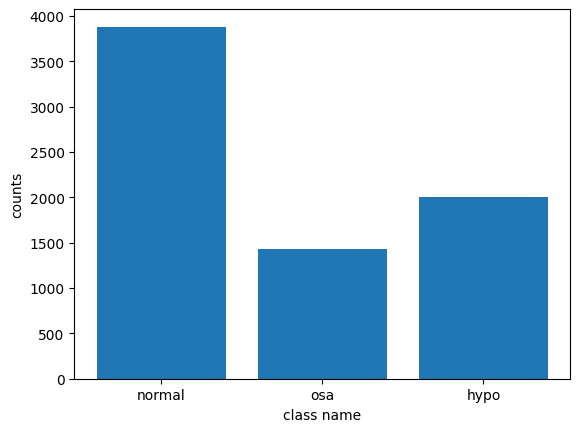

[3881 1429 2008]


In [6]:
X = np.array(signals + normal_signals)
y = np.array([mapping[label] for label in labels] + [0] * len(normal_signals))
_,counts=np.unique(y,return_counts=True)

class_names=['normal','osa','hypo']

plt.bar(class_names,counts)
plt.xlabel('class name')
plt.ylabel('counts')
plt.show()
print(counts)

In [11]:
for i in range(3):
    print(class_names[i])
    idx=np.where(y==i)
    idx=idx[0][10]
    print(X[idx])




normal
[94. 94. 94. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95.
 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95. 95.
 95. 95. 95. 95. 95. 95. 95. 95. 95. 94. 94. 94. 94. 94. 94. 94. 94. 95.
 94. 94. 95. 94. 95. 94.]
osa
[87. 87. 86. 86. 86. 88. 90. 92. 93. 94. 94. 95. 95. 95. 95. 95. 95. 95.
 94. 94. 94. 94. 94. 93. 93. 93. 92. 92. 92. 92. 92. 92. 92. 91. 91. 91.
 91. 91. 91. 91. 90. 90. 90. 90. 90. 90. 90. 90. 90. 90. 90. 90. 90. 89.
 89. 88. 88. 88. 87. 88.]
hypo
[93. 93. 93. 93. 93. 93. 93. 94. 94. 94. 94. 94. 94. 94. 94. 94. 94. 94.
 94. 94. 95. 95. 95. 95. 96. 96. 96. 96. 96. 96. 96. 96. 96. 96. 96. 96.
 96. 96. 96. 96. 96. 96. 96. 96. 96. 96. 96. 96. 96. 96. 96. 96. 96. 96.
 96. 96. 96. 96. 96. 96.]
